In [1]:
# from shuffle_gconvSE import *  #加载model_unet.py文件

In [2]:
#输出的路径
import os
name='4'
Path = '../sd/adam-0.0001/4-8/'
exp_path = os.path.join(Path, f'{1}/')
if os.path.exists(Path):
    i = 1
    while os.path.exists(os.path.join(Path, f'{i}/')):
        i += 1
    exp_path = os.path.join(Path, f'{i}/')

print(exp_path)  
    
path_1 = exp_path + '图片/'
path_2 = exp_path + 'heatmap/'
if not os.path.exists(path_1):
        os.makedirs(path_1)
if not os.path.exists(path_2):
        os.makedirs(path_2) 


../sd/adam-0.0001/4-8/5/


In [3]:
import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# os.environ["SM_FRAMEWORK"] = "tf.keras"
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.style.use("ggplot")
%matplotlib inline
import gc

from tqdm.notebook import trange, tqdm
from utils.loss import *
from utils.metrics import *
from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Dropout, concatenate, UpSampling2D,LSTM,DepthwiseConv2D,BatchNormalization
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from tensorflow.keras import backend as K

  
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.models import load_model

import random 
random_seed = 42
random.seed(random_seed) # set random seed for python
np.random.seed(random_seed) # set random seed for numpy
tf.random.set_seed(random_seed) # set random seed for tensorflow-cpu
os.environ['TF_DETERMINISTIC OPS'] = '1' # set random seed for tensorflow-gpu
## Seeding 
# seed = 2019
# random.seed = seed
# np.random.seed = seed
# tf.seed = seed

Instructions for updating:
non-resource variables are not supported in the long term


In [4]:
h, w = 256,256
border = 5 

# 读取训练图像

In [5]:
import glob
import gc
import numpy as np
from tqdm import tqdm
from keras.preprocessing.image import load_img, img_to_array
from skimage.transform import resize
import tensorflow as tf

# ── 训练集加载 ────────────────────────────────────────────────
train      = sorted(glob.glob("../dataset/train/images/*"))
train_mask = sorted(glob.glob("../dataset/train/masks/*"))

X = np.zeros((len(train),      h, w, 3), dtype=np.float32)
y = np.zeros((len(train_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(train, train_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X[n]  = x_img / 255.0
    y[n]  = mask  / 255.0

print(X.shape, y.shape)
gc.collect()

# ── 验证集加载 ────────────────────────────────────────────────
valid      = sorted(glob.glob("../dataset/valid/images/*"))
valid_mask = sorted(glob.glob("../dataset/valid/masks/*"))

X_valid = np.zeros((len(valid),      h, w, 3), dtype=np.float32)
y_valid = np.zeros((len(valid_mask), h, w, 1), dtype=np.float32)

for n, (img, mimg) in tqdm(enumerate(zip(valid, valid_mask))):
    x_img = img_to_array(load_img(img))
    x_img = resize(x_img, (h, w, 3), mode='constant', preserve_range=True)
    mask  = img_to_array(load_img(mimg, color_mode="grayscale"))
    mask  = resize(mask,  (h, w, 1), mode='constant', preserve_range=True)
    X_valid[n] = x_img / 255.0
    y_valid[n] = mask  / 255.0

print(X_valid.shape, y_valid.shape)
gc.collect()

# ── 数据增强函数 ──────────────────────────────────────────────
def augment_batch(X, y):
    X_aug = X.copy()
    y_aug = y.copy()
    for i in range(len(X_aug)):
        if np.random.rand() > 0.5:
            X_aug[i] = np.fliplr(X_aug[i])
            y_aug[i] = np.fliplr(y_aug[i])
        if np.random.rand() > 0.5:
            X_aug[i] = np.flipud(X_aug[i])
            y_aug[i] = np.flipud(y_aug[i])
        k = np.random.randint(0, 4)
        if k > 0:
            X_aug[i] = np.rot90(X_aug[i], k)
            y_aug[i] = np.rot90(y_aug[i], k)
        delta = np.random.uniform(-0.1, 0.1)
        X_aug[i] = np.clip(X_aug[i] + delta, 0.0, 1.0)
        factor = np.random.uniform(0.9, 1.1)
        X_aug[i] = np.clip((X_aug[i] - 0.5) * factor + 0.5, 0.0, 1.0)
    return X_aug, y_aug

# ── 生成器（每 epoch 动态增强，不翻倍内存）───────────────────
class AugmentGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=8, augment=True):
        self.X          = X
        self.y          = y
        self.batch_size = batch_size
        self.augment    = augment
        self.indices    = np.arange(len(X))

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        X_batch = self.X[batch_idx].copy()
        y_batch = self.y[batch_idx].copy()
        if self.augment:
            X_batch, y_batch = augment_batch(X_batch, y_batch)
        return X_batch, y_batch

    def on_epoch_end(self):
        np.random.shuffle(self.indices)

train_gen = AugmentGenerator(X,       y,       batch_size=16, augment=True)
valid_gen = AugmentGenerator(X_valid, y_valid, batch_size=16, augment=False)

print(f"训练集: {len(train_gen)} steps/epoch，验证集: {len(valid_gen)} steps/epoch")
gc.collect()

1575it [00:17, 89.02it/s]


(1575, 256, 256, 3) (1575, 256, 256, 1)


450it [00:05, 89.67it/s]

(450, 256, 256, 3) (450, 256, 256, 1)
训练集: 99 steps/epoch，验证集: 29 steps/epoch


0

In [6]:
# from model.Unet import *  #加载model_unet.py文件
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import *
from tensorflow.keras.preprocessing.image import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.models import load_model


def cse_block(prevlayer, prefix, reduction=4):
    channels = K.int_shape(prevlayer)[3]
    avg  = Lambda(lambda t: K.mean(t, axis=[1, 2]))(prevlayer)
    max_ = Lambda(lambda t: K.max(t,  axis=[1, 2]))(prevlayer)

    dense1 = Dense(max(channels // reduction, 4), activation='relu',
                   name=prefix + 'cse_lin1')
    dense2 = Dense(channels, activation='sigmoid',
                   name=prefix + 'cse_lin2')

    avg_out = dense2(dense1(avg))
    max_out = dense2(dense1(max_))
    att = Add()([avg_out, max_out])

    reweighted = Multiply()([prevlayer, att])
    return Add()([reweighted, prevlayer])


def sse_block(prevlayer, prefix, kernel_size=7):
    spatial_avg = Lambda(lambda t: K.mean(t, axis=-1, keepdims=True))(prevlayer)
    spatial_max = Lambda(lambda t: K.max(t,  axis=-1, keepdims=True))(prevlayer)
    spatial = Concatenate()([spatial_avg, spatial_max])

    att_large = Conv2D(1, (kernel_size, kernel_size), padding='same',
                       activation='sigmoid', kernel_initializer='he_normal',
                       name=prefix + '_conv_l')(spatial)
    att_small = Conv2D(1, (3, 3), padding='same',
                       activation='sigmoid', kernel_initializer='he_normal',
                       name=prefix + '_conv_s')(spatial)

    att = Average()([att_large, att_small])
    return Multiply(name=prefix + '_mul')([prevlayer, att])


def csse_block(x, prefix, sse_kernel=7):
    cse = cse_block(x, prefix)
    sse = sse_block(x, prefix, kernel_size=sse_kernel)
    x = Add(name=prefix + '_csse_mul')([cse, sse])
    return x


def conv2d_block(input_tensor, n_filters, kernel_size = 3, batchnorm = True):
    """Function to add 2 convolutional layers with the parameters passed to it"""
    # first layer
    x = Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
              kernel_initializer = 'he_normal', padding = 'same')(input_tensor)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
#     second layer
    x = Conv2D(filters = n_filters, kernel_size = (kernel_size, kernel_size),\
              kernel_initializer = 'he_normal', padding = 'same')(x)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)
    
    return x

class ViTBlock(tf.keras.layers.Layer):
    def __init__(self, num_heads=4, projection_dim=256,
                 transformer_units=[512, 256], **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.projection_dim = projection_dim
        self.transformer_units = transformer_units

    def build(self, input_shape):
        self.patch_embed = Conv2D(
            filters=self.projection_dim,
            kernel_size=1, strides=1, padding='same'
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.mha = MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.projection_dim // self.num_heads
        )
        self.add1 = Add()
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([
            Dense(self.transformer_units[0], activation='relu'),
            Dense(self.projection_dim)
        ])
        self.add2 = Add()

    def call(self, inputs):
        x = self.patch_embed(inputs)
        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]

        x  = tf.reshape(x, (B, H * W, C))
        x1 = self.layernorm1(x)
        attn = self.mha(x1, x1)
        x2 = self.add1([x, attn])
        x3 = self.layernorm2(x2)
        x3 = self.ffn(x3)
        x4 = self.add2([x2, x3])
        x4 = tf.reshape(x4, (B, H, W, C))
        return x4

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads,
            "projection_dim": self.projection_dim,
            "transformer_units": list(self.transformer_units),
        })
        return config
    
class DilatedConvStem(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size=3, dilation_rate=1, dilation_rate2=None, **kwargs):
        super(DilatedConvStem, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.dilation_rate2 = dilation_rate2 if dilation_rate2 is not None else dilation_rate + 1

    def build(self, input_shape):
        self.conv1 = Conv2D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            dilation_rate=self.dilation_rate,
            kernel_initializer='he_normal',
            padding='same'
        )
        self.bn1 = BatchNormalization()
        self.act1 = Activation('relu')

        self.conv2 = Conv2D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            dilation_rate=self.dilation_rate2,
            kernel_initializer='he_normal',
            padding='same'
        )
        self.bn2 = BatchNormalization()
        self.act2 = Activation('relu')

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act2(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size,
            'dilation_rate': self.dilation_rate,
            'dilation_rate2': self.dilation_rate2,
        })
        return config         
def dual_path_refinement(x, n_filters, prefix='refine'):
    channels = n_filters * 4  # 与 c9 对齐

    # ── 路径 A：局部 (dilation=1) ──
    a = Conv2D(channels, (3, 3), padding='same', dilation_rate=1,
               kernel_initializer='he_normal',
               name=prefix + '_convA')(x)
    a = BatchNormalization(name=prefix + '_bnA')(a)
    a = Activation('relu')(a)

    # ── 路径 B：上下文 (dilation=3，等效 7×7) ──
    b = Conv2D(channels, (3, 3), padding='same', dilation_rate=3,
               kernel_initializer='he_normal',
               name=prefix + '_convB')(x)
    b = BatchNormalization(name=prefix + '_bnB')(b)
    b = Activation('relu')(b)

    # ── 门控软融合：用 1×1 conv 学一个 sigmoid 权重，零额外参数压力 ──
    # 比直接 Add 更灵活，让网络自适应决定每个位置偏向哪条路
    gate = Conv2D(channels, (1, 1), padding='same', activation='sigmoid',
                  kernel_initializer='he_normal',
                  name=prefix + '_gate')(Add(name=prefix + '_add_ab')([a, b]))
    out = Add(name=prefix + '_gated')([
        Multiply(name=prefix + '_gA')([a, gate]),
        Multiply(name=prefix + '_gB')([b, gate])  # 共享同一 gate，省一半参数
    ])

    # ── 轻量 SE (reduction=8，比原来 reduction=4 省一半) ──
    gap = GlobalAveragePooling2D(name=prefix + '_gap')(out)
    se  = Dense(max(channels // 8, 4), activation='relu',
                name=prefix + '_se1')(gap)
    se  = Dense(channels, activation='sigmoid',
                name=prefix + '_se2')(se)
    se  = Reshape((1, 1, channels), name=prefix + '_se_r')(se)
    out = Multiply(name=prefix + '_se_mul')([out, se])

    # ── 残差 + 输出 ──
    out = Add(name=prefix + '_skip')([out, x])
    return Conv2D(1, (1, 1), activation='sigmoid',
                  name=prefix + '_output')(out)

def Unet(nClasses=1, input_height=256, input_width=256):
    """Function to define the UNET Model with ViT module and Dilated Convolution Stem"""
    # Contracting Path
#     input_img = Input(shape=input_size)
    input_img = Input(shape=(input_height, input_width, 3))
    n_filters = 8
    dropout = 0.1
    batchnorm = True
    
    conv_stem = DilatedConvStem(filters=32,dilation_rate=1, dilation_rate2=1)
    c1 = conv_stem(input_img)
    c1 = conv2d_block(c1, n_filters * 4, kernel_size = 3, batchnorm = batchnorm)
    p1 = MaxPooling2D((2, 2))(c1)
    p1 = Dropout(dropout)(p1)
    
    conv_stem = DilatedConvStem(filters=64,dilation_rate=1, dilation_rate2=1)
    c2 = conv_stem(p1)
    c2 = conv2d_block(c2,n_filters * 8, kernel_size = 3, batchnorm = batchnorm)
    p2 = MaxPooling2D((2, 2))(c2)
    p2 = Dropout(dropout)(p2)
    
    conv_stem = DilatedConvStem(filters=128,dilation_rate=2, dilation_rate2=3)
    c3 = conv_stem(p2)
    c3 = conv2d_block(c3, n_filters * 16, kernel_size = 3, batchnorm = batchnorm)
    p3 = MaxPooling2D((2, 2))(c3)
    p3 = Dropout(dropout)(p3)
    
    conv_stem = DilatedConvStem(filters=256, dilation_rate=3, dilation_rate2=5)
    c4 = conv_stem(p3)
    c4 = conv2d_block(c4, n_filters * 32, kernel_size = 3, batchnorm = batchnorm)
    p4 = MaxPooling2D((2, 2))(c4)
    p4 = Dropout(dropout)(p4)

    c5 = conv2d_block(p4, n_filters * 64, kernel_size = 3, batchnorm = batchnorm)
    c5 = ViTBlock(projection_dim=512, transformer_units=[1024, 512])(c5)
#     c5 = Conv2D(n_filters * 64,3,activation='relu',padding='same',kernel_initializer='he_normal')(c5)
    c5 = SeparableConv2D(n_filters * 64, 3, activation='relu', padding='same', depthwise_initializer='he_normal', pointwise_initializer='he_normal')(c5)
    c5 = BatchNormalization()(c5)
    c5 = Activation('relu')(c5)
    
    u6 = UpSampling2D(size=(2, 2), interpolation='bilinear')(c5)
    u6 = concatenate([u6, c4])
    c6 = conv2d_block(u6, n_filters * 32, kernel_size=3, batchnorm=batchnorm)
    c6 = csse_block(c6, prefix="c6", sse_kernel=7)
    c6 = BatchNormalization()(c6)
    c6 = Activation('relu')(c6)

    u7 = UpSampling2D(size=(2, 2), interpolation='bilinear')(c6)
    u7 = concatenate([u7, c3])
    c7 = conv2d_block(u7, n_filters * 16, kernel_size=3, batchnorm=batchnorm)
    c7 = csse_block(c7, prefix="c7", sse_kernel=7)
    c7 = BatchNormalization()(c7)
    c7 = Activation('relu')(c7)

    u8 = UpSampling2D(size=(2, 2), interpolation='bilinear')(c7)
    u8 = concatenate([u8, c2])
    c8 = conv2d_block(u8, n_filters * 8, kernel_size=3, batchnorm=batchnorm)
    c8 = csse_block(c8, prefix="c8", sse_kernel=3)
    c8 = BatchNormalization()(c8)
    c8 = Activation('relu')(c8)

    u9 = UpSampling2D(size=(2, 2), interpolation='bilinear')(c8)
    u9 = concatenate([u9, c1])
    c9 = conv2d_block(u9, n_filters * 4, kernel_size=3, batchnorm=batchnorm)
    c9 = csse_block(c9, prefix="c9", sse_kernel=3)
    c9 = BatchNormalization()(c9)
    c9 = Activation('relu')(c9)

#     ===== 输出细化 =====
#     conv10 = Conv2D(n_filters * 4, (3, 3), padding='same')(c9)
#     conv10 = BatchNormalization()(conv10)
#     conv10 = Activation('relu')(conv10)

#     att_map = Conv2D(1, (1, 1), activation='sigmoid')(conv10)
#     conv10  = Multiply()([conv10, att_map])

#     conv11 = Conv2D(n_filters * 4, (3, 3), padding='same')(conv10)
#     conv11 = BatchNormalization()(conv11)
#     conv11 = Activation('relu')(conv11)
#     conv11 = Add()([conv10, conv11])

#     outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv11)
    # ===== 输出细化 =====
    outputs = dual_path_refinement(c9, n_filters=n_filters, prefix='refine')
    

    model = Model(inputs=[input_img], outputs=[outputs])
    return model




# 评价指标

In [7]:
# from tensorflow.python.framework import ops
#import tensorflow as tf
# from keras import backend as K
from tensorflow.keras import backend as K
from tensorflow.keras.losses import Loss  
from tensorflow.keras.callbacks import LearningRateScheduler
K.clear_session()

input_img = Input((h, w, 3), name='img')
# input_size =(h,w,3)
model = Unet()
learning_rate = 0.0001  # 根据需要调整学习率的值
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)



# optimizer = tf.keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=1e-5)
# optimizer = tf.keras.optimizers.Adamax(learning_rate=learning_rate)
# optimizer = tf.keras.optimizers.Nadam(learning_rate=learning_rate)

# ----------------------------
# 通用余弦退火回调
# ----------------------------
epochs = 200  # 总训练 epoch

class CosineLRScheduler(Callback):
    def __init__(self, initial_lr, total_epochs):
        super().__init__()
        self.initial_lr = initial_lr
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        lr = 0.5 * self.initial_lr * (1 + np.cos(np.pi * epoch / self.total_epochs))
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        print(f"Epoch {epoch+1}: Learning rate set to {lr:.6f}")

cosine_lr_callback = CosineLRScheduler(initial_lr=learning_rate, total_epochs=epochs)

# ----------------------------
# 编译模型
# ----------------------------
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.Recall(name='Recall'),
        tf.keras.metrics.Precision(name='Precision'),
        tf.keras.metrics.TruePositives(name='TP'),
        tf.keras.metrics.TrueNegatives(name='TN'),
        tf.keras.metrics.FalseNegatives(name='FN'),
        tf.keras.metrics.FalsePositives(name='FP'),
        'accuracy'
    ]
)

gc.collect()

Instructions for updating:
Colocations handled automatically by placer.


4

In [8]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 3  0           []                               
                                )]                                                                
                                                                                                  
 dilated_conv_stem (DilatedConv  (None, 256, 256, 32  10400      ['input_1[0][0]']                
 Stem)                          )                                                                 
                                                                                                  
 conv2d_2 (Conv2D)              (None, 256, 256, 32  9248        ['dilated_conv_stem[0][0]']      
                                )                                                             

In [9]:
Path = exp_path
checkpoint_path = os.path.join(Path, f'{name}.h5')
checkpoint = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True)
csv_logger = CSVLogger(Path+f'{name}.CSV',append=True) 

In [10]:
import os
from tensorflow.keras.models import Model
from tensorflow.keras.utils import plot_model
#from plot_model import plot_model

save_path = os.path.join(exp_path, f'{name}.png')

plot_model(model, to_file=save_path, show_shapes=True, show_layer_names=False, rankdir='TB', expand_nested=False, dpi=300)
# #模型保存在jupyter启动目录下
# #plot_model(model=model, to_file=save_path, show_shapes=True, dpi=200)

('You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) ', 'for plot_model/model_to_dot to work.')


In [11]:
results = model.fit(
    train_gen,
    epochs=200,
    validation_data=valid_gen,
    callbacks=[checkpoint, csv_logger,cosine_lr_callback]
)

Epoch 1: Learning rate set to 0.000100
Epoch 1/200
99/99 [==============================] - 29s 240ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.2713 - Recall: 0.0272 - Precision: 0.0106 - TP: 25848.0000 - TN: 99851392.0000 - FN: 924261.0000 - FP: 2417715.0000 - acc: 0.9676 - val_loss: 0.4440 - val_Recall: 0.0176 - val_Precision: 0.0115 - val_TP: 4182.0000 - val_TN: 28892124.0000 - val_FN: 234079.0000 - val_FP: 360815.0000 - val_acc: 0.9798
Epoch 2: Learning rate set to 0.000100
Epoch 2/200
99/99 [==============================] - 21s 210ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.1274 - Recall: 2.8418e-05 - Precision: 0.0017 - TP: 27.0000 - TN: 102252952.0000 - FN: 950082.0000 - FP: 16140.0000 - acc: 0.9906 - val_loss: 0.1414 - val_Recall: 0.0000e+00 - val_Precision: 0.0000e+00 - val_TP: 0.0000e+00 - val_TN: 29252938.0000 - val_FN: 238261.0000 - val_FP: 0.0000e+00 - val_acc: 0.9919
Epoch 3: Learning rate set to 0.000100
Epoch 3/200
99/99 [==============================] - 

99/99 [==============================] - 20s 206ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0264 - Recall: 0.3127 - Precision: 0.7298 - TP: 297066.0000 - TN: 102159096.0000 - FN: 653043.0000 - FP: 109989.0000 - acc: 0.9926 - val_loss: 0.0366 - val_Recall: 0.3235 - val_Precision: 0.5459 - val_TP: 77079.0000 - val_TN: 29188832.0000 - val_FN: 161182.0000 - val_FP: 64106.0000 - val_acc: 0.9924
Epoch 20: Learning rate set to 0.000098
Epoch 20/200
99/99 [==============================] - 21s 209ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0248 - Recall: 0.3694 - Precision: 0.7464 - TP: 350984.0000 - TN: 102149808.0000 - FN: 599125.0000 - FP: 119281.0000 - acc: 0.9930 - val_loss: 0.0242 - val_Recall: 0.4902 - val_Precision: 0.5588 - val_TP: 116797.0000 - val_TN: 29160712.0000 - val_FN: 121464.0000 - val_FP: 92229.0000 - val_acc: 0.9928
Epoch 21: Learning rate set to 0.000098
Epoch 21/200
99/99 [==============================] - 20s 206ms/step - batch: 49.0000 - size: 15.9091 - lo

99/99 [==============================] - 21s 209ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0206 - Recall: 0.4373 - Precision: 0.7819 - TP: 415448.0000 - TN: 102153192.0000 - FN: 534661.0000 - FP: 115916.0000 - acc: 0.9937 - val_loss: 0.0163 - val_Recall: 0.4929 - val_Precision: 0.8116 - val_TP: 117429.0000 - val_TN: 29225686.0000 - val_FN: 120832.0000 - val_FP: 27253.0000 - val_acc: 0.9950
Epoch 38: Learning rate set to 0.000092
Epoch 38/200
99/99 [==============================] - 20s 207ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0196 - Recall: 0.4668 - Precision: 0.7981 - TP: 443504.0000 - TN: 102156856.0000 - FN: 506605.0000 - FP: 112215.0000 - acc: 0.9940 - val_loss: 0.0214 - val_Recall: 0.5875 - val_Precision: 0.6479 - val_TP: 139984.0000 - val_TN: 29176872.0000 - val_FN: 98277.0000 - val_FP: 76070.0000 - val_acc: 0.9941
Epoch 39: Learning rate set to 0.000091
Epoch 39/200
99/99 [==============================] - 21s 209ms/step - batch: 49.0000 - size: 15.9091 - lo

99/99 [==============================] - 20s 203ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0156 - Recall: 0.5952 - Precision: 0.8143 - TP: 565512.0000 - TN: 102140072.0000 - FN: 384597.0000 - FP: 129002.0000 - acc: 0.9950 - val_loss: 0.0161 - val_Recall: 0.6937 - val_Precision: 0.6507 - val_TP: 165287.0000 - val_TN: 29164200.0000 - val_FN: 72974.0000 - val_FP: 88741.0000 - val_acc: 0.9945
Epoch 56: Learning rate set to 0.000082
Epoch 56/200
99/99 [==============================] - 20s 203ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0151 - Recall: 0.5971 - Precision: 0.8100 - TP: 567275.0000 - TN: 102136056.0000 - FN: 382834.0000 - FP: 133031.0000 - acc: 0.9950 - val_loss: 0.0179 - val_Recall: 0.6936 - val_Precision: 0.5640 - val_TP: 165268.0000 - val_TN: 29125180.0000 - val_FN: 72993.0000 - val_FP: 127757.0000 - val_acc: 0.9932
Epoch 57: Learning rate set to 0.000082
Epoch 57/200
99/99 [==============================] - 20s 204ms/step - batch: 49.0000 - size: 15.9091 - lo

99/99 [==============================] - 20s 203ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0134 - Recall: 0.6404 - Precision: 0.8192 - TP: 608452.0000 - TN: 102134768.0000 - FN: 341657.0000 - FP: 134325.0000 - acc: 0.9954 - val_loss: 0.0148 - val_Recall: 0.7297 - val_Precision: 0.6448 - val_TP: 173857.0000 - val_TN: 29157176.0000 - val_FN: 64404.0000 - val_FP: 95764.0000 - val_acc: 0.9946
Epoch 74: Learning rate set to 0.000071
Epoch 74/200
99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0128 - Recall: 0.6593 - Precision: 0.8238 - TP: 626417.0000 - TN: 102135080.0000 - FN: 323692.0000 - FP: 133994.0000 - acc: 0.9956 - val_loss: 0.0121 - val_Recall: 0.6474 - val_Precision: 0.7812 - val_TP: 154253.0000 - val_TN: 29209740.0000 - val_FN: 84008.0000 - val_FP: 43198.0000 - val_acc: 0.9957
Epoch 75: Learning rate set to 0.000070
Epoch 75/200
99/99 [==============================] - 20s 204ms/step - batch: 49.0000 - size: 15.9091 - los

...

99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0091 - Recall: 0.7600 - Precision: 0.8647 - TP: 722127.0000 - TN: 102156096.0000 - FN: 227982.0000 - FP: 112997.0000 - acc: 0.9967 - val_loss: 0.0099 - val_Recall: 0.7579 - val_Precision: 0.7970 - val_TP: 180583.0000 - val_TN: 29206936.0000 - val_FN: 57678.0000 - val_FP: 45998.0000 - val_acc: 0.9965
Epoch 128: Learning rate set to 0.000029
Epoch 128/200
99/99 [==============================] - 20s 203ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0088 - Recall: 0.7706 - Precision: 0.8704 - TP: 732121.0000 - TN: 102160120.0000 - FN: 217988.0000 - FP: 108983.0000 - acc: 0.9968 - val_loss: 0.0095 - val_Recall: 0.7434 - val_Precision: 0.8184 - val_TP: 177133.0000 - val_TN: 29213652.0000 - val_FN: 61128.0000 - val_FP: 39292.0000 - val_acc: 0.9966
Epoch 129: Learning rate set to 0.000029
Epoch 129/200
99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0084 - Recall: 0.7840 - Precision: 0.8725 - TP: 744877.0000 - TN: 102160176.0000 - FN: 205232.0000 - FP: 108887.0000 - acc: 0.9970 - val_loss: 0.0099 - val_Recall: 0.7450 - val_Precision: 0.8131 - val_TP: 177501.0000 - val_TN: 29212130.0000 - val_FN: 60760.0000 - val_FP: 40805.0000 - val_acc: 0.9966
Epoch 146: Learning rate set to 0.000018
Epoch 146/200
99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0085 - Recall: 0.7767 - Precision: 0.8732 - TP: 737932.0000 - TN: 102161984.0000 - FN: 212177.0000 - FP: 107122.0000 - acc: 0.9969 - val_loss: 0.0096 - val_Recall: 0.7696 - val_Precision: 0.7970 - val_TP: 183363.0000 - val_TN: 29206224.0000 - val_FN: 54898.0000 - val_FP: 46716.0000 - val_acc: 0.9966
Epoch 147: Learning rate set to 0.000017
Epoch 147/200
99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0078 - Recall: 0.7994 - Precision: 0.8774 - TP: 759505.0000 - TN: 102162912.0000 - FN: 190604.0000 - FP: 106165.0000 - acc: 0.9971 - val_loss: 0.0095 - val_Recall: 0.7578 - val_Precision: 0.8196 - val_TP: 180557.0000 - val_TN: 29213192.0000 - val_FN: 57704.0000 - val_FP: 39747.0000 - val_acc: 0.9967
Epoch 164: Learning rate set to 0.000008
Epoch 164/200
99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0079 - Recall: 0.7961 - Precision: 0.8792 - TP: 756361.0000 - TN: 102165176.0000 - FN: 193748.0000 - FP: 103904.0000 - acc: 0.9971 - val_loss: 0.0094 - val_Recall: 0.7528 - val_Precision: 0.8157 - val_TP: 179354.0000 - val_TN: 29212428.0000 - val_FN: 58907.0000 - val_FP: 40513.0000 - val_acc: 0.9966
Epoch 165: Learning rate set to 0.000008
Epoch 165/200
99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0076 - Recall: 0.8006 - Precision: 0.8807 - TP: 760648.0000 - TN: 102166024.0000 - FN: 189461.0000 - FP: 103074.0000 - acc: 0.9972 - val_loss: 0.0094 - val_Recall: 0.7667 - val_Precision: 0.8127 - val_TP: 182669.0000 - val_TN: 29210832.0000 - val_FN: 55592.0000 - val_FP: 42108.0000 - val_acc: 0.9967
Epoch 182: Learning rate set to 0.000002
Epoch 182/200
99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0076 - Recall: 0.8030 - Precision: 0.8810 - TP: 762931.0000 - TN: 102166048.0000 - FN: 187178.0000 - FP: 103053.0000 - acc: 0.9972 - val_loss: 0.0094 - val_Recall: 0.7687 - val_Precision: 0.8151 - val_TP: 183142.0000 - val_TN: 29211410.0000 - val_FN: 55119.0000 - val_FP: 41535.0000 - val_acc: 0.9967
Epoch 183: Learning rate set to 0.000002
Epoch 183/200
99/99 [==============================] - 20s 203ms/step - batch: 49.0000 - size: 15.9091 -

99/99 [==============================] - 20s 203ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0076 - Recall: 0.8051 - Precision: 0.8825 - TP: 764926.0000 - TN: 102167208.0000 - FN: 185183.0000 - FP: 101892.0000 - acc: 0.9972 - val_loss: 0.0095 - val_Recall: 0.7722 - val_Precision: 0.8101 - val_TP: 183984.0000 - val_TN: 29209812.0000 - val_FN: 54277.0000 - val_FP: 43126.0000 - val_acc: 0.9967
Epoch 200: Learning rate set to 0.000000
Epoch 200/200
99/99 [==============================] - 20s 202ms/step - batch: 49.0000 - size: 15.9091 - loss: 0.0075 - Recall: 0.8018 - Precision: 0.8834 - TP: 761815.0000 - TN: 102168552.0000 - FN: 188294.0000 - FP: 100555.0000 - acc: 0.9972 - val_loss: 0.0095 - val_Recall: 0.7707 - val_Precision: 0.8106 - val_TP: 183617.0000 - val_TN: 29210038.0000 - val_FN: 54644.0000 - val_FP: 42902.0000 - val_acc: 0.9967


In [12]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result
outputpath=Path+f'{name}.xlsx'
df_result.to_excel(outputpath,index=True,header=True)

In [13]:
df_result = pd.DataFrame(results.history)
df_result.sort_values('val_loss', ascending=True, inplace = True)
df_result

,loss,Recall,Precision,TP,TN,FN,FP,acc,val_loss,val_Recall,val_Precision,val_TP,val_TN,val_FN,val_FP,val_acc
142,0.008379,0.778495,0.873938,739655.0,102162400.0,210454.0,106692.0,0.996928,0.009234,0.766911,0.809822,182725.0,29210024.0,55536.0,42911.0,0.996662
159,0.007837,0.798382,0.876300,758550.0,102162032.0,191559.0,107078.0,0.997107,0.009236,0.764082,0.819223,182051.0,29212766.0,56210.0,40173.0,0.996732
138,0.008451,0.786216,0.870032,746991.0,102157496.0,203118.0,111588.0,0.996951,0.009257,0.763423,0.813436,181894.0,29211220.0,56367.0,41718.0,0.996674
154,0.008204,0.788352,0.872448,749020.0,102159568.0,201089.0,109507.0,0.996991,0.009310,0.756351,0.815507,180209.0,29212172.0,58052.0,40769.0,0.996649
157,0.007964,0.792144,0.876852,752623.0,102163376.0,197486.0,105701.0,0.997063,0.009311,0.767360,0.807127,182832.0,29209246.0,55429.0,43690.0,0.996639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0.065888,0.000032,0.000412,30.0,102196344.0,950079.0,72754.0,0.990091,0.058480,0.000000,0.000000,0.0,29252938.0,238261.0,0.0,0.991921
3,0.074115,0.000000,0.000000,0.0,102268232.0,950109.0,854.0,0.990787,0.071190,0.000000,0.000000,0.0,29252938.0,238261.0,0.0,0.991921
2,0.090297,0.000006,0.001975,6.0,102266072.0,950103.0,3032.0,0.990766,0.093581,0.000000,0.000000,0.0,29252938.0,238261.0,0.0,0.991921
1,0.127601,0.000028,0.001670,27.0,102252952.0,950082.0,16140.0,0.990639,0.141426,0.000000,0.000000,0.0,29252938.0,238261.0,0.0,0.991921


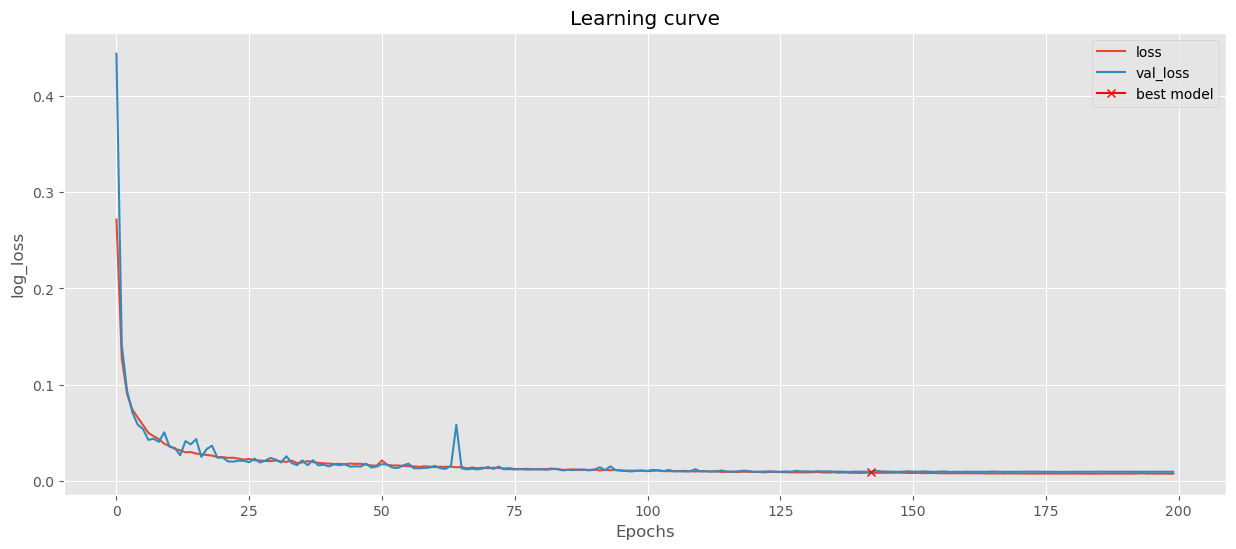

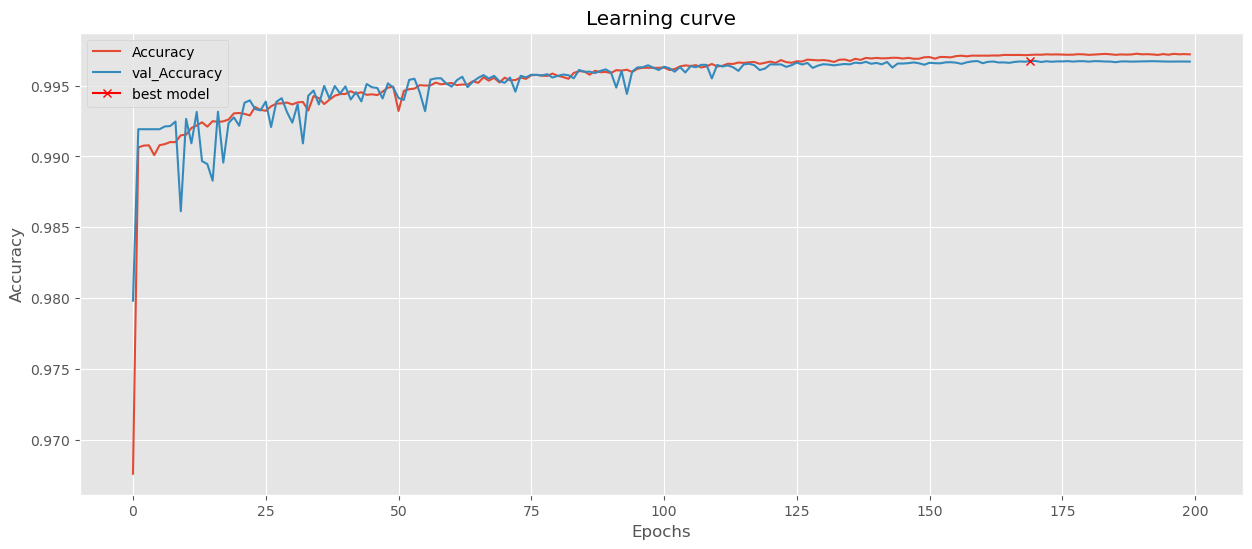

In [14]:
plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(results.history["loss"], label="loss")
plt.plot(results.history["val_loss"], label="val_loss")
plt.plot(np.argmin(results.history["val_loss"]), np.min(results.history["val_loss"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("log_loss")
plt.legend();

plt.figure(figsize = (15,6))
plt.title("Learning curve")
plt.plot(results.history["acc"], label="Accuracy")
plt.plot(results.history["val_acc"], label="val_Accuracy")
plt.plot(np.argmax(results.history["val_acc"]), np.max(results.history["val_acc"]), marker="x", color="r", label="best model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();
# plt.figure(figsize = (15,6))
# plt.title("Learning curve")
# plt.plot(results.history["accuracy"], label="Accuracy")
# plt.plot(results.history["val_accuracy"], label="val_Accuracy")
# plt.plot(np.argmax(results.history["val_accuracy"]), np.max(results.history["val_accuracy"]), marker="x", color="r", label="best model")
# plt.xlabel("Epochs")
# plt.ylabel("Accuracy")
# plt.legend();

# 模型测试

In [15]:
import numpy as np
import cv2
import os
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *


class ViTBlock(tf.keras.layers.Layer):
    def __init__(self, num_heads=4, projection_dim=256,
                 transformer_units=[512, 256], **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.projection_dim = projection_dim
        self.transformer_units = transformer_units

    def build(self, input_shape):
        self.patch_embed = Conv2D(
            filters=self.projection_dim,
            kernel_size=1, strides=1, padding='same'
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.mha = MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.projection_dim // self.num_heads
        )
        self.add1 = Add()
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([
            Dense(self.transformer_units[0], activation='relu'),
            Dense(self.projection_dim)
        ])
        self.add2 = Add()

    def call(self, inputs):
        x = self.patch_embed(inputs)
        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]

        x  = tf.reshape(x, (B, H * W, C))
        x1 = self.layernorm1(x)
        attn = self.mha(x1, x1)
        x2 = self.add1([x, attn])
        x3 = self.layernorm2(x2)
        x3 = self.ffn(x3)
        x4 = self.add2([x2, x3])
        x4 = tf.reshape(x4, (B, H, W, C))
        return x4

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads,
            "projection_dim": self.projection_dim,
            "transformer_units": list(self.transformer_units),
        })
        return config

class DilatedConvStem(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size=3, dilation_rate=1, dilation_rate2=None, **kwargs):
        super(DilatedConvStem, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.dilation_rate2 = dilation_rate2 if dilation_rate2 is not None else dilation_rate + 1

    def build(self, input_shape):
        self.conv1 = Conv2D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            dilation_rate=self.dilation_rate,
            kernel_initializer='he_normal',
            padding='same'
        )
        self.bn1 = BatchNormalization()
        self.act1 = Activation('relu')

        self.conv2 = Conv2D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            dilation_rate=self.dilation_rate2,
            kernel_initializer='he_normal',
            padding='same'
        )
        self.bn2 = BatchNormalization()
        self.act2 = Activation('relu')

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act2(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size,
            'dilation_rate': self.dilation_rate,
            'dilation_rate2': self.dilation_rate2,
        })
        return config    


# ── 加载模型 ──────────────────────────────────────────────────
model = tf.keras.models.load_model(r'D:\tensorflow\tf\WTB\sd\adam-0.0001\4-8\5\4.h5', custom_objects={
    'DilatedConvStem': DilatedConvStem,
    'ViTBlock': ViTBlock,
    'K': K,
})

# ── 评估 ──────────────────────────────────────────────────────
IMAGE_DIR = 'D:/tensorflow/tf/WTB/dataset/test/images'
MASK_DIR  = 'D:/tensorflow/tf/WTB/dataset/test/masks'

true_labels, pred_labels = [], []

for fname in sorted(f for f in os.listdir(IMAGE_DIR) if f.endswith('.png')):
    # 图像
    img = cv2.imread(os.path.join(IMAGE_DIR, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (256, 256)) / 255.0

    # 掩码
    mask_path = os.path.join(MASK_DIR, fname.replace('.png', '_mask.png'))
    if not os.path.exists(mask_path):
        print(f"跳过（无掩码）: {fname}")
        continue
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (256, 256))

    # 预测
    pred = model.predict(np.expand_dims(img, axis=0), verbose=0)[0]

    true_labels.extend((mask > 0).astype(np.uint8).flatten())
    pred_labels.extend((pred > 0.5).astype(np.uint8).flatten())

# ── 指标输出 ──────────────────────────────────────────────────
t, p = np.array(true_labels), np.array(pred_labels)
inter, union = np.logical_and(t, p).sum(), np.logical_or(t, p).sum()

print("="*35)
print(f"  Accuracy  : {accuracy_score(t, p):.4f}")
print(f"  Precision : {precision_score(t, p, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(t, p, zero_division=0):.4f}")
print(f"  F1 Score  : {f1_score(t, p, zero_division=0):.4f}")
print(f"  MCC       : {matthews_corrcoef(t, p):.4f}")
print(f"  IoU       : {inter / union if union else 0:.4f}")
print("="*35)

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
  Accuracy  : 0.9968
  Precision : 0.8208
  Recall    : 0.7537
  F1 Score  : 0.7858
  MCC       : 0.7849
  IoU       : 0.6472


In [16]:
import time
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.image import load_img, img_to_array

    
class ViTBlock(tf.keras.layers.Layer):
    def __init__(self, num_heads=4, projection_dim=256,
                 transformer_units=[512, 256], **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.projection_dim = projection_dim
        self.transformer_units = transformer_units

    def build(self, input_shape):
        self.patch_embed = Conv2D(
            filters=self.projection_dim,
            kernel_size=1, strides=1, padding='same'
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.mha = MultiHeadAttention(
            num_heads=self.num_heads,
            key_dim=self.projection_dim // self.num_heads
        )
        self.add1 = Add()
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.ffn = tf.keras.Sequential([
            Dense(self.transformer_units[0], activation='relu'),
            Dense(self.projection_dim)
        ])
        self.add2 = Add()

    def call(self, inputs):
        x = self.patch_embed(inputs)
        B = tf.shape(x)[0]
        H = tf.shape(x)[1]
        W = tf.shape(x)[2]
        C = tf.shape(x)[3]

        x  = tf.reshape(x, (B, H * W, C))
        x1 = self.layernorm1(x)
        attn = self.mha(x1, x1)
        x2 = self.add1([x, attn])
        x3 = self.layernorm2(x2)
        x3 = self.ffn(x3)
        x4 = self.add2([x2, x3])
        x4 = tf.reshape(x4, (B, H, W, C))
        return x4

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_heads": self.num_heads,
            "projection_dim": self.projection_dim,
            "transformer_units": list(self.transformer_units),
            
        })
        return config

class DilatedConvStem(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size=3, dilation_rate=1, dilation_rate2=None, **kwargs):
        super(DilatedConvStem, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.dilation_rate2 = dilation_rate2 if dilation_rate2 is not None else dilation_rate + 1

    def build(self, input_shape):
        self.conv1 = Conv2D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            dilation_rate=self.dilation_rate,
            kernel_initializer='he_normal',
            padding='same'
        )
        self.bn1 = BatchNormalization()
        self.act1 = Activation('relu')

        self.conv2 = Conv2D(
            filters=self.filters,
            kernel_size=self.kernel_size,
            dilation_rate=self.dilation_rate2,
            kernel_initializer='he_normal',
            padding='same'
        )
        self.bn2 = BatchNormalization()
        self.act2 = Activation('relu')

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.act2(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            'filters': self.filters,
            'kernel_size': self.kernel_size,
            'dilation_rate': self.dilation_rate,
            'dilation_rate2': self.dilation_rate2,
        })
        return config    





def load_and_preprocess_image(image_path, target_size=(256, 256)):
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img) / 255.0
    return img_array.astype(np.float32)


def test_fps(
    input_folder,
    model_path='4.h5',
    warmup_runs=10,
    image_size=(256, 256),
    use_xla=True
):
    from tensorflow.keras import backend as K  # ← 修复：加载前先导入 K

    # ── 1. 加载模型（把 K 加入 custom_objects）───────────────
    print("Loading model...")
    model = tf.keras.models.load_model(model_path, custom_objects={
        'DilatedConvStem': DilatedConvStem,
        'ViTBlock':        ViTBlock,
        'K':               K,          # ← 关键修复：Lambda 层用到了 K 
    })
    print("Model loaded.\n")

    # ── 2. 读取图片路径 ──────────────────────────────────────
    file_paths = sorted([
        os.path.join(input_folder, f)
        for f in os.listdir(input_folder)
        if f.lower().endswith('.png')
    ])
    if not file_paths:
        print("No PNG images found.")
        return

    dummy = np.random.rand(1, *image_size, 3).astype(np.float32)

    # ── 3. 编译 tf.function ──────────────────────────────────
    print(f"Compiling inference function (jit_compile={use_xla})...")
    try:
        infer_fn = tf.function(model, jit_compile=use_xla)
        _ = infer_fn(dummy)
        print("Compiled successfully.\n")
    except Exception as e:
        print(f"XLA failed ({e})\nFalling back to jit_compile=False...")
        infer_fn = tf.function(model, jit_compile=False)
        _ = infer_fn(dummy)
        print("Compiled (no XLA).\n")

    # ── 4. Warm-up ───────────────────────────────────────────
    print(f"Warming up ({warmup_runs} runs)...")
    for _ in range(warmup_runs):
        _ = infer_fn(dummy)
    print("Warm-up done.\n")

    # ── 5. 推理计时 ──────────────────────────────────────────
    inference_times = []
    print(f"Benchmarking {len(file_paths)} images...\n")

    for idx, image_path in enumerate(file_paths):
        image        = load_and_preprocess_image(image_path, target_size=image_size)
        input_tensor = tf.constant(np.expand_dims(image, axis=0))

        start = time.perf_counter()
        _     = infer_fn(input_tensor)
        end   = time.perf_counter()

        inference_times.append(end - start)

        if (idx + 1) % 10 == 0 or (idx + 1) == len(file_paths):
            print(f"  [{idx + 1:>4}/{len(file_paths)}]  {(end - start)*1000:.1f} ms")

    # ── 6. 输出结果 ──────────────────────────────────────────
    times  = np.array(inference_times)
    avg_ms = times.mean() * 1000
    std_ms = times.std()  * 1000
    min_ms = times.min()  * 1000
    max_ms = times.max()  * 1000
    p50_ms = np.percentile(times, 50) * 1000
    p95_ms = np.percentile(times, 95) * 1000
    p99_ms = np.percentile(times, 99) * 1000
    fps    = 1.0 / times.mean()

    print("\n" + "="*45)
    print("        🚀  Inference Performance")
    print("="*45)
    print(f"  Total images      : {len(file_paths)}")
    print(f"  Avg latency       : {avg_ms:.2f} ms  (±{std_ms:.2f})")
    print(f"  Min / Max         : {min_ms:.2f} ms / {max_ms:.2f} ms")
    print(f"  P50 / P95 / P99   : {p50_ms:.2f} / {p95_ms:.2f} / {p99_ms:.2f} ms")
    print(f"  FPS               : {fps:.2f}")
    print("="*45)


# ── 入口 ──────────────────────────────────────────────────────
if __name__ == "__main__":
    test_fps(
        input_folder = "D:/tensorflow/tf/WTB/dataset/test/images",
        model_path   = r'D:\tensorflow\tf\WTB\sd\adam-0.0001\4-8\4\4.h5',
        warmup_runs  = 10,
        image_size   = (256, 256),
        use_xla      = True
    )

Loading model...
Model loaded.

Compiling inference function (jit_compile=True)...
Compiled successfully.

Warming up (10 runs)...
Warm-up done.

Benchmarking 225 images...

  [  10/225]  5.0 ms
  [  20/225]  5.5 ms
  [  30/225]  5.7 ms
  [  40/225]  5.1 ms
  [  50/225]  5.3 ms
  [  60/225]  6.1 ms
  [  70/225]  5.0 ms
  [  80/225]  4.8 ms
  [  90/225]  6.3 ms
  [ 100/225]  5.4 ms
  [ 110/225]  5.1 ms
  [ 120/225]  6.2 ms
  [ 130/225]  5.5 ms
  [ 140/225]  5.7 ms
  [ 150/225]  5.8 ms
  [ 160/225]  5.8 ms
  [ 170/225]  4.9 ms
  [ 180/225]  6.0 ms
  [ 190/225]  5.3 ms
  [ 200/225]  5.5 ms
  [ 210/225]  6.1 ms
  [ 220/225]  5.5 ms
  [ 225/225]  4.8 ms

        🚀  Inference Performance
  Total images      : 225
  Avg latency       : 5.44 ms  (±0.42)
  Min / Max         : 4.75 ms / 7.16 ms
  P50 / P95 / P99   : 5.33 / 6.25 / 6.86 ms
  FPS               : 183.68
